# Bayesian MCMC analysis

Estimate total mass and distance from an observed waveform using a Gaussian-noise posterior and a Metropolis-Hastings chain.

## Scientific method



The parameter vector is $\theta=(M,D)$, where $M$ is total mass in solar masses and $D$ is luminosity distance in Mpc. The posterior combines a Gaussian-noise likelihood with independent Gaussian priors centred on the initial estimates. A random-walk Metropolis-Hastings chain samples this posterior; all conclusions should be supported by trace stability, acceptance behaviour, and credible intervals rather than a single best-fit curve.

In [ ]:
from pathlib import Path

import sys



import matplotlib.pyplot as plt

import numpy as np

from scipy.stats import ks_2samp



PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / 'data').exists():

    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))



from gravitational_wave_mcmc import (

    align_to_merger,

    chirp_mass,

    component_masses,

    estimate_noise,

    load_waveform,

    log_posterior,

    metropolis_hastings,

    orbital_separation,

    scale_waveform,

    schwarzschild_radii,

)

In [ ]:
# Load the observed and reference waveforms and estimate noise
observed = align_to_merger(load_waveform(PROJECT_ROOT / 'data' / 'raw' / 'Observedwaveform.csv'))
reference = load_waveform(PROJECT_ROOT / 'data' / 'raw' / 'reference_waveform_40Msun_1Mpc.csv')
_, noise_std = estimate_noise(observed, start_time=0.05)

# Define priors, initial values, and proposal standard deviations for MCMC
prior_means = np.array([77.0, 1750.0])
prior_stds = np.array([5.0, 100.0])
initial = prior_means.copy()
proposal_stds = np.array([0.1, 10.0])

# Define the posterior function for MCMC
def posterior(theta):
    return log_posterior(
        theta, observed, reference, noise_std, 40.0, 1.0,
        prior_means, prior_stds
    )

## Model specification



For independent Gaussian strain errors, the log likelihood is



$$\log L(\theta)=-\frac{1}{2}\sum_i\left[\frac{y_i-h_i(\theta)}{\sigma}\right]^2.$$



The prior regularises the two-parameter fit around the exploratory estimates while positivity constraints exclude nonphysical masses and distances. This is deliberately a simple model: calibration uncertainty, correlated detector noise, and parameter degeneracies are not included.

Median mass: 76.90 solar masses
Median distance: 1705.43 Mpc


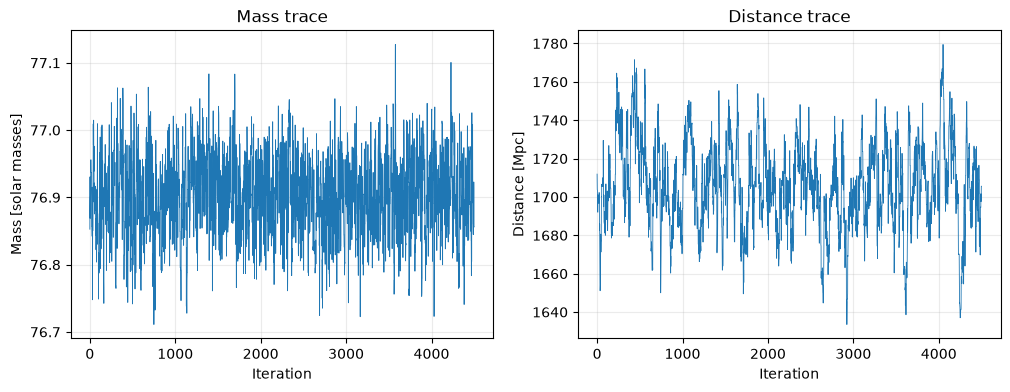

In [ ]:
# Run the Metropolis-Hastings MCMC algorithm and analyze the results
samples, log_probabilities = metropolis_hastings(
    posterior, initial, proposal_stds, iterations=5000,
    rng=np.random.default_rng(42)
)
burned = samples[500:]
estimate = np.median(burned, axis=0)
print(f'Median mass: {estimate[0]:.2f} solar masses')
print(f'Median distance: {estimate[1]:.2f} Mpc')

# Plot the trace of the MCMC samples for mass and distance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(burned[:, 0], lw=0.6)
axes[0].set(xlabel='Iteration', ylabel='Mass [solar masses]', title='Mass trace')
axes[1].plot(burned[:, 1], lw=0.6)
axes[1].set(xlabel='Iteration', ylabel='Distance [Mpc]', title='Distance trace')
for axis in axes:
    axis.grid(alpha=0.25)
plt.show()

In [ ]:
# Compute acceptance rate and credible intervals for the MCMC samples
acceptance_rate = np.mean(np.any(np.diff(samples, axis=0) != 0, axis=1))
mass_interval = np.percentile(burned[:, 0], [5, 95])
distance_interval = np.percentile(burned[:, 1], [5, 95])

# Print the acceptance rate and the 90% credible intervals for mass and distance
print(f'Acceptance rate: {acceptance_rate:.3f}')
print(f'90% mass credible interval: [{mass_interval[0]:.2f}, {mass_interval[1]:.2f}] solar masses')
print(f'90% distance credible interval: [{distance_interval[0]:.2f}, {distance_interval[1]:.2f}] Mpc')

Acceptance rate: 0.532
90% mass credible interval: [76.80, 77.00] solar masses
90% distance credible interval: [1668.60, 1743.44] Mpc


## Chain diagnostics



The trace plots should fluctuate around a stable region without long periods of immobility or systematic drift. The acceptance rate is reported alongside the traces because an apparently stable chain can still be poorly mixed. The reported intervals are equal-tailed 90% credible intervals from the post-burn-in samples; they quantify posterior uncertainty under the stated model and priors.

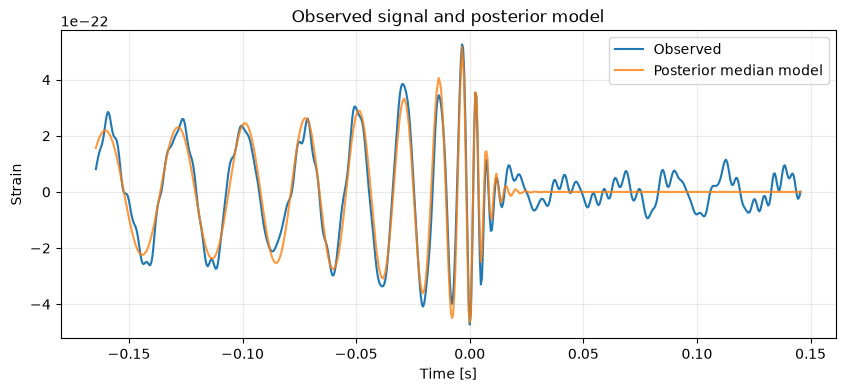

In [ ]:
# Plot the observed signal and the posterior median model
best_fit = scale_waveform(observed.time, reference, 40.0, 1.0, estimate[0], estimate[1])
plt.figure(figsize=(10, 4))
plt.plot(observed.time, observed.strain, label='Observed')
plt.plot(observed.time, best_fit, label='Posterior median model', alpha=0.8)
plt.xlabel('Time [s]')
plt.ylabel('Strain')
plt.title('Observed signal and posterior model')
plt.legend()
plt.grid(alpha=0.25)
plt.show()

In [ ]:
# Perform KS test between observed signal and posterior median model before merger
mcmc_pre_merger = (observed.time < 0) & np.isfinite(best_fit)
mcmc_ks = ks_2samp(observed.strain[mcmc_pre_merger], best_fit[mcmc_pre_merger])

# Print the results of the KS test
print('Posterior-model KS test is evaluated only before merger.')
print(f'KS statistic: {mcmc_ks.statistic:.3f}')
print(f'KS p-value: {mcmc_ks.pvalue:.4f}')

Posterior-model KS test is evaluated only before merger.
KS statistic: 0.050
KS p-value: 0.7853


In [ ]:
# Estimate the physical parameters of the binary system based on the posterior median model
mass_ratio = 1.0
total_mass = float(estimate[0])
primary_mass, secondary_mass = component_masses(mass_ratio, total_mass)
chirp = chirp_mass(mass_ratio, total_mass)
radii = schwarzschild_radii(primary_mass, secondary_mass)


# Determine the merger time based on the minimum of the observed strain
merger_time = observed.time[np.argmin(observed.strain)]
peak_window = (observed.time > -0.015) & (observed.time < -0.010)
previous_peak_time = observed.time[peak_window][np.argmax(observed.strain[peak_window])]
gravitational_wave_period = merger_time - previous_peak_time
separation = orbital_separation(primary_mass, secondary_mass, gravitational_wave_period)

# Print the estimated physical parameters of the binary system
print(f'Chirp mass: {chirp:.2f} solar masses')
print(f'Component masses: {primary_mass:.2f}, {secondary_mass:.2f} solar masses')
print(f'Schwarzschild radii: {radii[0]:.2f}, {radii[1]:.2f} km')
print(f'Gravitational-wave period: {gravitational_wave_period:.4f} s')
print(f'Estimated orbital separation: {separation:.2f} km')

Chirp mass: 33.47 solar masses
Component masses: 38.45, 38.45 solar masses
Schwarzschild radii: 113.56, 113.56 km
Gravitational-wave period: 0.0137 s
Estimated orbital separation: 578.19 km


## Astrophysical interpretation



For an equal-mass system, $q=M_2/M_1=1$ and the posterior total mass is divided equally between the components. The chirp mass controls the leading inspiral phase evolution. The Schwarzschild radius is calculated as $R_s=2GM/c^2$; this is distinct from the gravitational radius $GM/c^2$ used in some simplified treatments. The separation estimate uses the fact that the gravitational-wave period is half the orbital period for a circular binary.



These derived quantities are conditional on the equal-mass assumption and the peak-based period estimate. They should therefore be presented as an interpretable physical scenario, not as additional independently measured parameters.

## Posterior predictive comparison



The final overlay compares the observed strain with the waveform evaluated at the posterior median parameters. Agreement before merger indicates that the inferred mass gives a compatible phase evolution and the inferred distance gives a compatible amplitude. The post-merger residual structure is not treated as evidence for new source physics here because the model and likelihood use a simple stationary Gaussian noise approximation.